Filtered departees: 5,101
Filtered returnees: 2,918


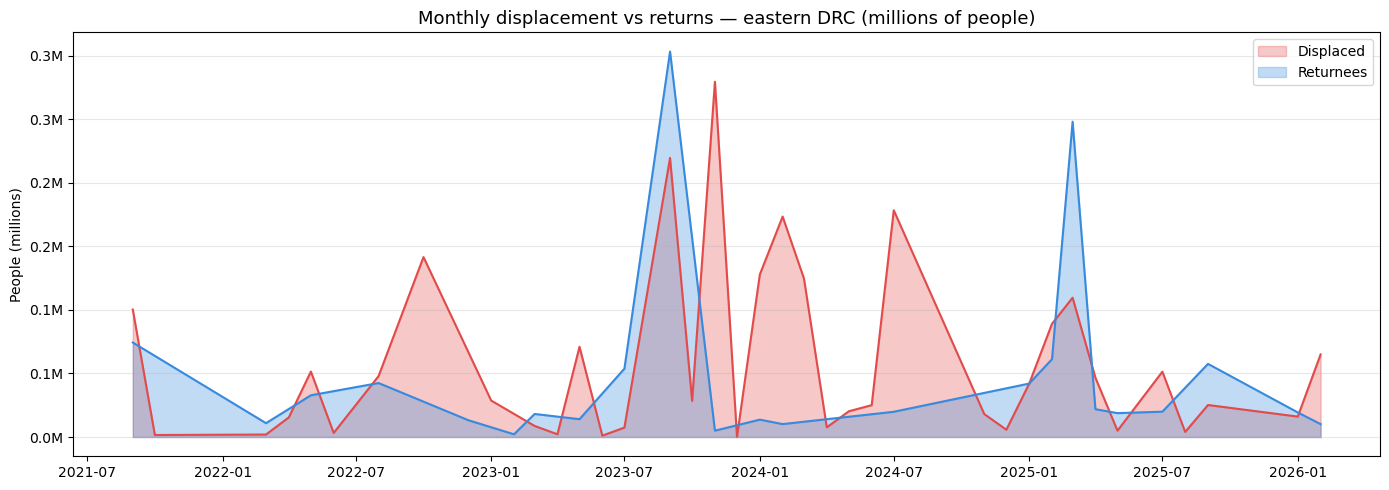

Saved fig1_monthly_totals.png


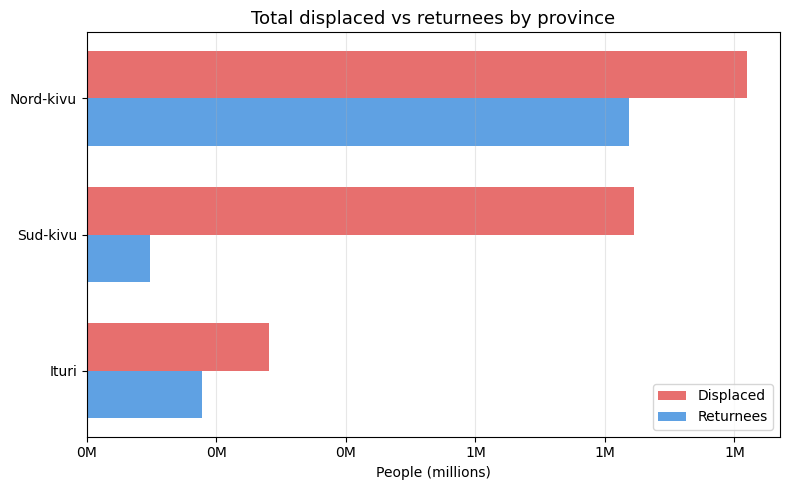

Saved fig2_province_totals.png


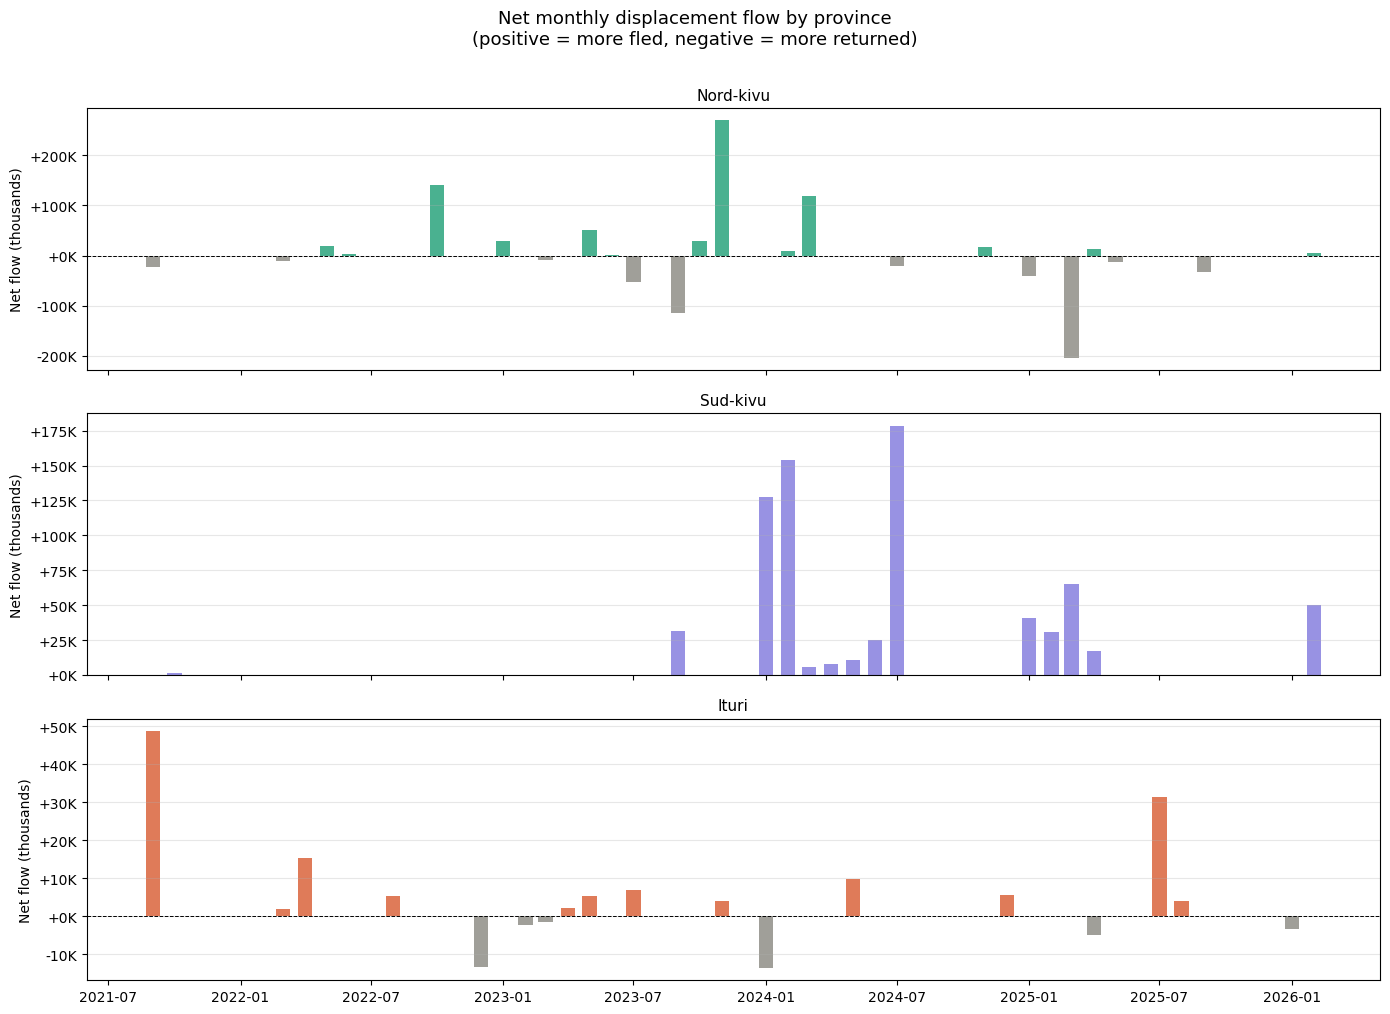

Saved fig3_net_flow_by_province.png


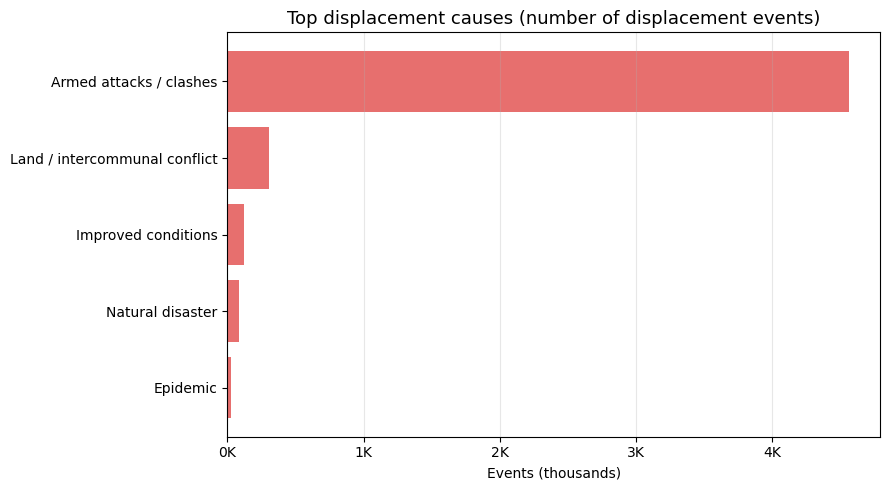

Saved fig4_causes.png


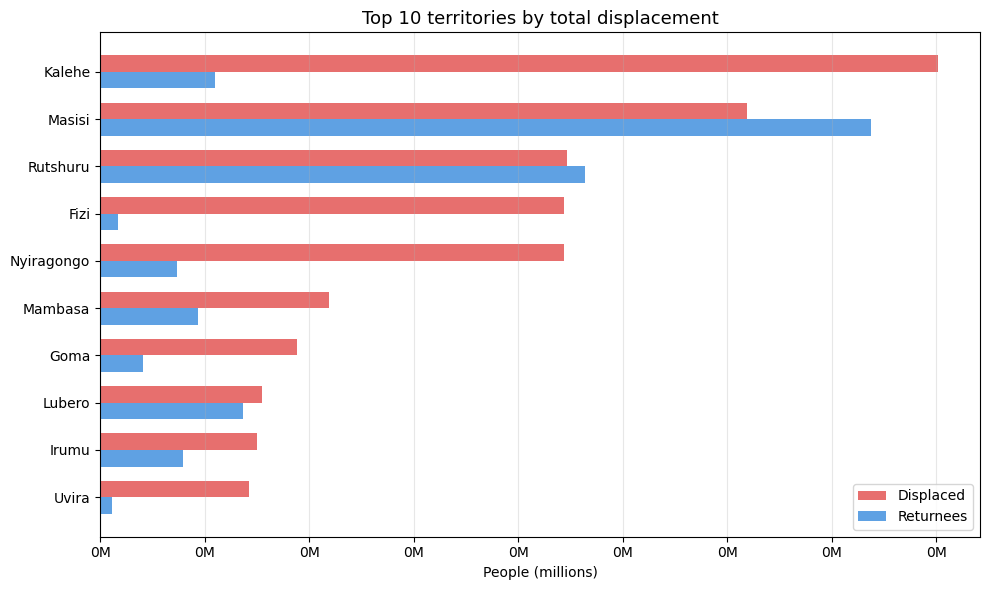

Saved fig5_top_admin2.png

── Summary ──────────────────────────────────────────
Total displaced (persons):        2,145,300
Total returnees (persons):        1,112,733
Net displacement:                 1,032,567
Date range: Sep 2021 → Feb 2026

Top displacement cause: Armed attacks / clashes
Top return cause:       Improved conditions


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

dep = pd.read_csv('/Users/jackzipper/QSS20/final_project/final_project_data/departees_eastern_drc.csv')
ret = pd.read_csv('/Users/jackzipper/QSS20/final_project/final_project_data/returnees_eastern_drc.csv')

dep['movement_date'] = pd.to_datetime(dep['movement_date'], errors='coerce')
ret['movement_date'] = pd.to_datetime(ret['movement_date'], errors='coerce')
dep['snapshot_month'] = pd.to_datetime(dep['snapshot_month'])
ret['snapshot_month'] = pd.to_datetime(ret['snapshot_month'])

# ── FILTER: only keep events where movement occurred in that snapshot month ──
dep = dep[
    (dep['movement_date'].dt.year == dep['snapshot_month'].dt.year) &
    (dep['movement_date'].dt.month == dep['snapshot_month'].dt.month)
]
ret = ret[
    (ret['movement_date'].dt.year == ret['snapshot_month'].dt.year) &
    (ret['movement_date'].dt.month == ret['snapshot_month'].dt.month)
]

# ── Deduplicate: each event ID counted only once ────────────────────────────
dep = dep.sort_values('snapshot_month').drop_duplicates(subset=['id'], keep='first')
ret = ret.sort_values('snapshot_month').drop_duplicates(subset=['id'], keep='first')

# ── Filter to eastern provinces ─────────────────────────────────────────────
eastern_provinces = ['Nord-kivu', 'Sud-kivu', 'Ituri']
dep = dep[dep['admin1_label'].isin(eastern_provinces)]
ret = ret[ret['admin1_label'].isin(eastern_provinces)]

# ── Translate cause labels to English ───────────────────────────────────────
cause_translations = {
    'Attaques, affrontements armées': 'Armed attacks / clashes',
    'Conflits fonciers, intercommunautaires': 'Land / intercommunal conflict',
    'Catastrophe naturelle': 'Natural disaster',
    'Amélioration des conditions': 'Improved conditions',
    'AméLioration des conditions': 'Improved conditions',
    'AmÃ©lioration des conditions': 'Improved conditions',
    'Epidemie': 'Epidemic',
    'Autre': 'Other',
    'Malnutrition': 'Malnutrition',
}
dep['cause_label'] = dep['cause_label'].str.strip().replace(cause_translations)
ret['cause_label'] = ret['cause_label'].str.strip().replace(cause_translations)

print(f"Filtered departees: {len(dep):,}")
print(f"Filtered returnees: {len(ret):,}")

# ── 1. Monthly totals: displaced vs returnees ───────────────────────────────
dep_monthly = dep.groupby('snapshot_month')['person'].sum()
ret_monthly = ret.groupby('snapshot_month')['person'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(dep_monthly.index, dep_monthly / 1e6, alpha=0.3, color='#E24B4A', label='Displaced')
ax.fill_between(ret_monthly.index, ret_monthly / 1e6, alpha=0.3, color='#378ADD', label='Returnees')
ax.plot(dep_monthly.index, dep_monthly / 1e6, color='#E24B4A', linewidth=1.5)
ax.plot(ret_monthly.index, ret_monthly / 1e6, color='#378ADD', linewidth=1.5)
ax.set_title('Monthly displacement vs returns — eastern DRC (millions of people)', fontsize=13)
ax.set_ylabel('People (millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/jackzipper/QSS20/final_project/output/fig1_monthly_totals.png', dpi=150)
plt.show()
print("Saved fig1_monthly_totals.png")

# ── 2. Total displacement by province ───────────────────────────────────────
dep_prov = dep.groupby('admin1_label')['person'].sum().sort_values()
ret_prov = ret.groupby('admin1_label')['person'].sum().reindex(dep_prov.index)

x = np.arange(len(dep_prov))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(x + width/2, dep_prov / 1e6, width, color='#E24B4A', alpha=0.8, label='Displaced')
ax.barh(x - width/2, ret_prov / 1e6, width, color='#378ADD', alpha=0.8, label='Returnees')
ax.set_yticks(x)
ax.set_yticklabels(dep_prov.index)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.set_title('Total displaced vs returnees by province', fontsize=13)
ax.set_xlabel('People (millions)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/jackzipper/QSS20/final_project/output/fig2_province_totals.png', dpi=150)
plt.show()
print("Saved fig2_province_totals.png")

# ── 3. Net monthly flow per province ────────────────────────────────────────
dep_pm = dep.groupby(['admin1_label', 'snapshot_month'])['person'].sum().reset_index()
ret_pm = ret.groupby(['admin1_label', 'snapshot_month'])['person'].sum().reset_index()
panel = pd.merge(dep_pm, ret_pm, on=['admin1_label', 'snapshot_month'],
                 how='outer', suffixes=('_dep', '_ret')).fillna(0)
panel['net'] = panel['person_dep'] - panel['person_ret']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = ['#1D9E75', '#7F77DD', '#D85A30']
for ax, province, color in zip(axes, eastern_provinces, colors):
    pdata = panel[panel['admin1_label'] == province].sort_values('snapshot_month')
    ax.bar(pdata['snapshot_month'], pdata['net'] / 1e3,
           color=[color if v >= 0 else '#888780' for v in pdata['net']],
           alpha=0.8, width=20)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(province, fontsize=11)
    ax.set_ylabel('Net flow (thousands)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}K'))
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Net monthly displacement flow by province\n(positive = more fled, negative = more returned)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/Users/jackzipper/QSS20/final_project/output/fig3_net_flow_by_province.png', dpi=150)
plt.show()
print("Saved fig3_net_flow_by_province.png")

# ── 4. Top displacement causes ──────────────────────────────────────────────
causes = dep['cause_label'].value_counts().head(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(causes.index, causes.values / 1e3, color='#E24B4A', alpha=0.8)
ax.set_title('Top displacement causes (number of displacement events)', fontsize=13)
ax.set_xlabel('Events (thousands)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/jackzipper/QSS20/final_project/output/fig4_causes.png', dpi=150)
plt.show()
print("Saved fig4_causes.png")

# ── 5. Top 10 admin2 territories by displacement ────────────────────────────
top_admin2_dep = dep.groupby('admin2_label')['person'].sum().nlargest(10).sort_values()
top_admin2_ret = ret.groupby('admin2_label')['person'].sum().reindex(top_admin2_dep.index).fillna(0)

x = np.arange(len(top_admin2_dep))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(x + width/2, top_admin2_dep / 1e6, width, color='#E24B4A', alpha=0.8, label='Displaced')
ax.barh(x - width/2, top_admin2_ret / 1e6, width, color='#378ADD', alpha=0.8, label='Returnees')
ax.set_yticks(x)
ax.set_yticklabels(top_admin2_dep.index)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.set_title('Top 10 territories by total displacement', fontsize=13)
ax.set_xlabel('People (millions)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/jackzipper/QSS20/final_project/output/fig5_top_admin2.png', dpi=150)
plt.show()
print("Saved fig5_top_admin2.png")

# ── Summary stats ────────────────────────────────────────────────────────────
print("\n── Summary ──────────────────────────────────────────")
print(f"Total displaced (persons):  {dep['person'].sum():>15,.0f}")
print(f"Total returnees (persons):  {ret['person'].sum():>15,.0f}")
print(f"Net displacement:           {(dep['person'].sum() - ret['person'].sum()):>15,.0f}")
print(f"Date range: {dep['snapshot_month'].min().strftime('%b %Y')} → {dep['snapshot_month'].max().strftime('%b %Y')}")
print(f"\nTop displacement cause: {dep['cause_label'].value_counts().index[0]}")
print(f"Top return cause:       {ret['cause_label'].value_counts().index[0]}")